---
## STEP 0 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)

print('Imports OK')

Imports OK


---
## STEP 1 — Chargement & aperçu

In [2]:
df = pd.read_csv(r'C:\Users\HP\Downloads\raw_moteur.csv')
print(f'Shape : {df.shape}')
df.head()

Shape : (8184, 22)


,Lien_index,Marque,Modèle,Année,Kilométrage,Carburant,Transmission,Carrosserie,Couleur,Puissance fiscale,...,ville,État du véhicule,Airbags,Navigation GPS,Ordinateur de bord,Limiteur de vitesse,Climatisation,Intérieur cuir,Radar de recul,Cylindrée
0,0,Skoda,Superb,2019.0,"107,000 km",Diesel,Automatique,NaN,NaN,NaN,...,Casablanca,1,0,0,0,0,0,0,0,NaN
1,1,Nissan,Qashqai,2013.0,"178,000 km",Diesel,Manuelle,SUV et 4x4,Noir,7.0,...,NaN,0,0,0,0,0,0,0,0,NaN
2,2,Volkswagen,Golf 5,2007.0,"249,000 km",Diesel,Manuelle,Coupé,Bleu marine,8.0,...,Casablanca,0,1,1,0,0,1,0,0,NaN
3,3,Peugeot,2008,2014.0,"168,000 km",Diesel,Manuelle,NaN,NaN,6.0,...,Tanger,0,0,0,0,0,0,0,0,NaN
4,4,Citroën,C5,2019.0,"129,000 km",Diesel,Automatique,NaN,NaN,8.0,...,Casablanca,0,0,0,0,0,0,0,0,NaN


In [3]:
# Résumé des valeurs manquantes (héritage de la partie B)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Manquants': missing, '%': missing_pct}).sort_values('%', ascending=False)

,Manquants,%
Cylindrée,8182,99.98
Carrosserie,4864,59.43
Couleur,3593,43.90
Nombre de portes,2463,30.10
Puissance fiscale,1862,22.75
prix,1218,14.88
ville,691,8.44
Transmission,90,1.10
Carburant,45,0.55
Année,43,0.53


---
## STEP 2 — Suppression des colonnes inutiles

D'après la partie B :
- **`Cylindrée`** : 99.98 % de NaN → inutilisable, on supprime
- **`Lien_index`** : simple identifiant technique, aucune valeur prédictive
- **`Couleur`** : 43.9 % de NaN + faible corrélation avec le prix → on supprime
- **`Carrosserie`** : 59.4 % de NaN → trop de données manquantes
- **`Nombre de portes`** : 30 % de NaN, quasi-constante (95 % = 5 portes) → on supprime

In [4]:
cols_to_drop = ['Cylindrée', 'Lien_index', 'Couleur', 'Carrosserie', 'Nombre de portes']
df.drop(columns=cols_to_drop, inplace=True)
print(f'Colonnes supprimées : {cols_to_drop}')
print(f'Shape après suppression : {df.shape}')

Colonnes supprimées : ['Cylindrée', 'Lien_index', 'Couleur', 'Carrosserie', 'Nombre de portes']
Shape après suppression : (8184, 17)


---
## STEP 3 — Nettoyage des types

**`Kilométrage`** est une chaîne de caractères (`'107,000 km'`) → on extrait la valeur numérique.

In [5]:
# Exemple avant nettoyage
print('Avant :', df['Kilométrage'].head(3).tolist())

# Supprime 'km', virgules, espaces → conversion en float
df['Kilométrage'] = (
    df['Kilométrage']
    .astype(str)
    .str.replace(r'[^\d]', '', regex=True)
    .replace('', np.nan)
    .astype(float)
)

print('Après :', df['Kilométrage'].head(3).tolist())
print(f'Type : {df["Kilométrage"].dtype}')

Avant : ['107,000 km', '178,000 km', '249,000 km']
Après : [107000.0, 178000.0, 249000.0]
Type : float64


---
## STEP 4 — Suppressions de lignes (avant split)

On effectue uniquement les **suppressions de lignes** ici — elles sont déterministes et ne dépendent d'aucune statistique calculée sur les données.  
L'imputation par médiane/mode sera faite **après le split** pour éviter le data leakage.

| Colonne | Stratégie | Raison |
|---------|-----------|--------|
| `prix` | **Suppression des lignes** | C'est la cible — on ne peut pas l'imputer |
| `Marque`, `Modèle` | **Suppression des lignes** | Peu de NaN (0.39 %), colonnes essentielles |
| `Année`, `Kilométrage`, `Puissance fiscale` | Imputation médiane → **après split** | Statistique dépendante des données |
| `Carburant`, `Transmission` | Imputation mode → **après split** | Statistique dépendante des données |
| `ville` | Remplacement par 'Inconnu' → **après split** | Neutre, pas de statistique |


In [6]:
print(f'Shape avant traitement NaN : {df.shape}')

# 1. Supprimer les lignes sans prix (cible manquante)
df.dropna(subset=['prix'], inplace=True)
print(f'Après suppression prix NaN          : {df.shape}')

# 2. Supprimer les lignes sans Marque ou Modèle (peu nombreuses, essentielles)
df.dropna(subset=['Marque', 'Modèle'], inplace=True)
print(f'Après suppression Marque/Modèle NaN : {df.shape}')

Shape avant traitement NaN : (8184, 17)
Après suppression prix NaN          : (6966, 17)
Après suppression Marque/Modèle NaN : (6966, 17)


---
## STEP 5 — Outliers (sur le dataset complet, avant split)

On applique la méthode **IQR** sur `prix`, `Kilométrage`, `Puissance fiscale`.  
> **Note :** Appliquer le filtrage IQR avant le split est acceptable ici car on retire des lignes aberrantes qui ne devraient pas exister dans aucun sous-ensemble. Pour une rigueur maximale, on pourrait le faire uniquement sur le train set — mais le risque de leakage est faible pour cette opération.

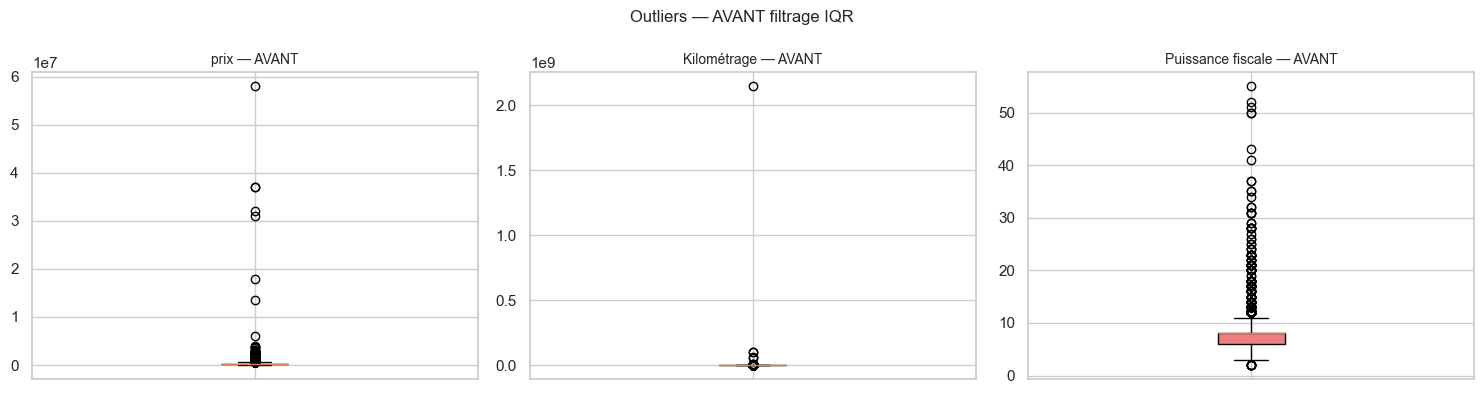

In [7]:
# Visualisation AVANT filtrage
cols_outlier = ['prix', 'Kilométrage', 'Puissance fiscale']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(cols_outlier):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='lightcoral'))
    axes[i].set_title(f'{col} — AVANT', fontsize=10)
    axes[i].tick_params(axis='x', labelbottom=False)
plt.suptitle('Outliers — AVANT filtrage IQR', fontsize=12)
plt.tight_layout()
plt.show()

In [8]:
def remove_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = len(df)
    df = df[(df[col] >= lower) & (df[col] <= upper)]
    after = len(df)
    print(f'  {col}: [{lower:.0f} – {upper:.0f}] → {before - after} lignes supprimées ({after} restantes)')
    return df

print(f'Shape avant outliers : {df.shape}')
for col in cols_outlier:
    df = remove_outliers_iqr(df, col)

print(f'\nShape après outliers : {df.shape}')

Shape avant outliers : (6966, 17)
  prix: [-105000 – 535000] → 429 lignes supprimées (6537 restantes)
  Kilométrage: [-104000 – 328000] → 184 lignes supprimées (6353 restantes)
  Puissance fiscale: [3 – 11] → 1654 lignes supprimées (4699 restantes)

Shape après outliers : (4699, 17)


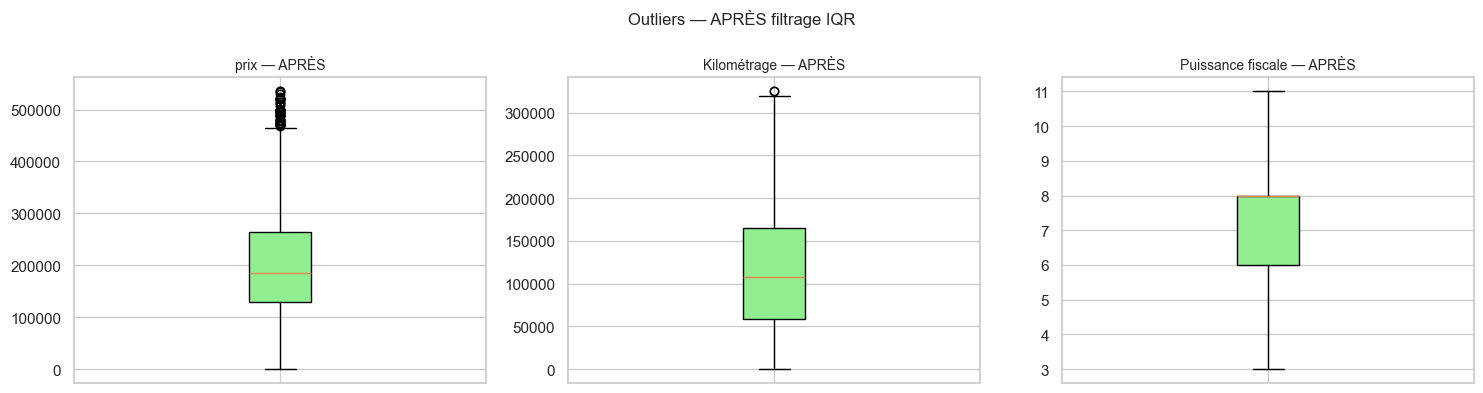

In [9]:
# Visualisation APRÈS filtrage
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(cols_outlier):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='lightgreen'))
    axes[i].set_title(f'{col} — APRÈS', fontsize=10)
    axes[i].tick_params(axis='x', labelbottom=False)
plt.suptitle('Outliers — APRÈS filtrage IQR', fontsize=12)
plt.tight_layout()
plt.show()

---
## STEP 6 — Feature Engineering

On crée de nouvelles variables pertinentes à partir des données existantes.  
> Ces opérations sont **déterministes** (pas de statistiques apprises) → elles peuvent s'appliquer avant le split.

In [10]:
CURRENT_YEAR = 2026

# 1. Âge de la voiture
df['age_voiture'] = CURRENT_YEAR - df['Année']

# 2. Kilométrage par an (proxy d'usure)
df['km_par_an'] = df.apply(
    lambda row: row['Kilométrage'] / row['age_voiture'] if row['age_voiture'] > 0 else row['Kilométrage'],
    axis=1
)

# 3. Score d'options (nombre d'équipements de confort présents)
option_cols = ['Airbags', 'Navigation GPS', 'Ordinateur de bord',
               'Limiteur de vitesse', 'Climatisation', 'Intérieur cuir', 'Radar de recul']
df['score_options'] = df[option_cols].sum(axis=1)

# 4. Voiture récente (binaire : année >= 2018)
df['voiture_recente'] = (df['Année'] >= 2018).astype(int)

print('Features créées :')
print('  - age_voiture')
print('  - km_par_an')
print('  - score_options')
print('  - voiture_recente')
df[['Année', 'age_voiture', 'Kilométrage', 'km_par_an', 'score_options', 'voiture_recente']].head()

Features créées :
  - age_voiture
  - km_par_an
  - score_options
  - voiture_recente


,Année,age_voiture,Kilométrage,km_par_an,score_options,voiture_recente
1,2013.0,13.0,178000.0,13692.307692,0,0
2,2007.0,19.0,249000.0,13105.263158,3,0
3,2014.0,12.0,168000.0,14000.000000,0,0
4,2019.0,7.0,129000.0,18428.571429,0,1
6,2022.0,4.0,130000.0,32500.000000,0,1


In [11]:
X = df.drop(columns=['prix'])
y = df['prix']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train : {X_train.shape[0]} lignes  ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test  : {X_test.shape[0]} lignes  ({X_test.shape[0]/len(X)*100:.0f}%)')

Train : 3759 lignes  (80%)
Test  : 940 lignes  (20%)


---
## STEP 4bis — Imputation des valeurs manquantes (fit sur train)

On calcule médiane et mode **uniquement sur le train set**, puis on applique ces valeurs aux deux sets.

| Colonne | Stratégie |
|---------|----------|
| `Année`, `Kilométrage`, `Puissance fiscale` | Médiane du train |
| `Carburant`, `Transmission` | Mode du train |
| `ville` | 'Inconnu' (pas de statistique) |

In [12]:
# Imputation par médiane — fit sur train, transform sur train + test
for col in ['Année', 'Kilométrage', 'Puissance fiscale']:
    median_val = X_train[col].median()          #  calculé sur train uniquement
    X_train[col] = X_train[col].fillna(median_val)
    X_test[col]  = X_test[col].fillna(median_val)  #  même valeur appliquée au test
    print(f'  {col} → médiane (train) = {median_val}')

# Imputation par mode — fit sur train, transform sur train + test
for col in ['Carburant', 'Transmission']:
    mode_val = X_train[col].mode()[0]           #  calculé sur train uniquement
    X_train[col] = X_train[col].fillna(mode_val)
    X_test[col]  = X_test[col].fillna(mode_val)
    print(f'  {col} → mode (train) = {mode_val}')

# Ville : pas de statistique → on peut appliquer directement
X_train['ville'] = X_train['ville'].fillna('Inconnu')
X_test['ville']  = X_test['ville'].fillna('Inconnu')

# Vérification
print(f'\nNaN restants — train : {X_train.isnull().sum().sum()}')
print(f'NaN restants — test  : {X_test.isnull().sum().sum()}')

  Année → médiane (train) = 2019.0
  Kilométrage → médiane (train) = 107400.0
  Puissance fiscale → médiane (train) = 7.0
  Carburant → mode (train) = Diesel
  Transmission → mode (train) = Automatique

NaN restants — train : 0
NaN restants — test  : 0


---
## STEP 7 — Encodage des variables catégorielles (fit sur train)

| Variable | Cardinalité | Méthode |
|----------|-------------|---------|
| `Carburant` | Faible (~5 valeurs) | **LabelEncoder** |
| `Transmission` | Faible (~3 valeurs) | **LabelEncoder** |
| `État du véhicule` | Binaire (0/1) | Déjà encodé |
| `Marque` | Moyenne (~40 valeurs) | **Target Encoding** (moyenne prix par marque — train only) |
| `ville` | Moyenne (~50 valeurs) | **Target Encoding** (moyenne prix par ville — train only) |
| `Modèle` | Haute (>200 valeurs) | **Target Encoding** (moyenne prix par modèle — train only) |

In [13]:
# --- LabelEncoder pour Carburant et Transmission ---
# fit sur train uniquement → transform sur train + test
# Sécurité : les catégories inconnues dans le test sont remplacées par la valeur la plus fréquente du train

def safe_label_encode(le, series):
    """Transform avec fallback pour les catégories inconnues (non vues au train)."""
    known = set(le.classes_)
    fallback = le.classes_[0]  # classe la plus fréquente après fit
    return le.transform(series.map(lambda x: x if x in known else fallback))

le_carburant    = LabelEncoder()
le_transmission = LabelEncoder()

X_train['Carburant_enc']    = le_carburant.fit_transform(X_train['Carburant'].astype(str))         #  fit + transform
X_test['Carburant_enc']     = safe_label_encode(le_carburant, X_test['Carburant'].astype(str))      #  transform only + fallback

X_train['Transmission_enc'] = le_transmission.fit_transform(X_train['Transmission'].astype(str))   # fit + transform
X_test['Transmission_enc']  = safe_label_encode(le_transmission, X_test['Transmission'].astype(str)) #  transform only + fallback

print('Carburant     :', dict(zip(le_carburant.classes_, le_carburant.transform(le_carburant.classes_))))
print('Transmission  :', dict(zip(le_transmission.classes_, le_transmission.transform(le_transmission.classes_))))

# Sauvegarder les encodeurs pour l'inférence future
joblib.dump(le_carburant,    '../Downloads/le_carburant.pkl')
joblib.dump(le_transmission, '../Downloads/le_transmission.pkl')
print('\nEncodeurs sauvegardés.')

Carburant     : {'Diesel': np.int64(0), 'Essence': np.int64(1), 'Hybride': np.int64(2), 'Électrique': np.int64(3)}
Transmission  : {'Automatique': np.int64(0), 'Manuelle': np.int64(1)}

Encodeurs sauvegardés.


In [14]:
# --- Target Encoding pour Marque, Modèle et ville ---
# Moyenne prix calculée sur le TRAIN SET uniquement
# Fallback pour les catégories inconnues dans le test : moyenne globale du train

global_mean_train = y_train.mean()  #  moyenne globale du train

target_encoders = {}

for col in ['Marque', 'Modèle', 'ville']:
    # Concat sur l'index partagé — plus robuste que join
    train_df = pd.concat([X_train[[col]], y_train], axis=1)  #  train only
    target_mean = train_df.groupby(col)['prix'].mean()
    target_encoders[col] = target_mean

    X_train[f'{col}_enc'] = X_train[col].map(target_mean).fillna(global_mean_train)  # 
    X_test[f'{col}_enc']  = X_test[col].map(target_mean).fillna(global_mean_train)   #  même mapping, fallback pour inconnues

    n_unseen = X_test[col].map(target_mean).isna().sum()
    print(f'  {col} → {X_train[col].nunique()} catégories (train) | {n_unseen} inconnues dans le test (→ fallback global mean)')

# Sauvegarder les mappings de target encoding
joblib.dump(target_encoders, '../Downloads/target_encoders.pkl')
print('\nTarget encoders sauvegardés.')

  Marque → 58 catégories (train) | 2 inconnues dans le test (→ fallback global mean)
  Modèle → 352 catégories (train) | 32 inconnues dans le test (→ fallback global mean)
  ville → 21 catégories (train) | 0 inconnues dans le test (→ fallback global mean)

Target encoders sauvegardés.


---
## STEP 8 — Feature Selection

On supprime les colonnes textuelles originales et on analyse la corrélation **sur le train set**.

In [15]:
# Supprimer les colonnes textuelles originales (remplacées par les encodées)
cols_raw_text = ['Marque', 'Modèle', 'Carburant', 'Transmission', 'ville', 'Année']
X_train.drop(columns=cols_raw_text, inplace=True)
X_test.drop(columns=cols_raw_text, inplace=True)

print(f'Colonnes finales ({len(X_train.columns)}) :')
print(X_train.columns.tolist())

Colonnes finales (19) :
['Kilométrage', 'Puissance fiscale', 'État du véhicule', 'Airbags', 'Navigation GPS', 'Ordinateur de bord', 'Limiteur de vitesse', 'Climatisation', 'Intérieur cuir', 'Radar de recul', 'age_voiture', 'km_par_an', 'score_options', 'voiture_recente', 'Carburant_enc', 'Transmission_enc', 'Marque_enc', 'Modèle_enc', 'ville_enc']


Corrélation avec prix (triée, sur train) :
Modèle_enc             0.764
Transmission_enc      -0.614
Marque_enc             0.541
age_voiture           -0.523
voiture_recente        0.488
Puissance fiscale      0.330
Kilométrage           -0.280
Intérieur cuir         0.226
ville_enc              0.199
Navigation GPS         0.177
km_par_an              0.166
Ordinateur de bord     0.166
score_options          0.154
Radar de recul         0.136
Limiteur de vitesse    0.130
Climatisation          0.072
État du véhicule       0.063
Carburant_enc         -0.024
Airbags                0.002


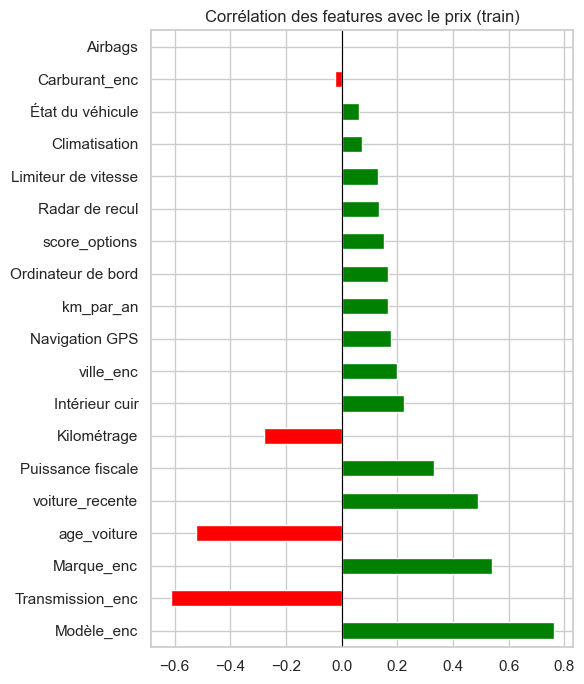

In [16]:
# Matrice de corrélation calculée sur le TRAIN SET uniquement
train_with_target = X_train.copy()
train_with_target['prix'] = y_train.values

corr = train_with_target.corr(numeric_only=True)
corr_with_prix = corr['prix'].drop('prix').sort_values(key=abs, ascending=False)

print('Corrélation avec prix (triée, sur train) :')
print(corr_with_prix.round(3).to_string())

plt.figure(figsize=(6, 7))
corr_with_prix.plot(kind='barh', color=['green' if x > 0 else 'red' for x in corr_with_prix])
plt.title('Corrélation des features avec le prix (train)', fontsize=12)
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [17]:
# Supprimer les features avec corrélation très faible (< 0.03 en valeur absolue) — décision basée sur train
low_corr_threshold = 0.03
low_corr_cols = corr_with_prix[corr_with_prix.abs() < low_corr_threshold].index.tolist()

if low_corr_cols:
    print(f'Colonnes faiblement corrélées supprimées : {low_corr_cols}')
    X_train.drop(columns=low_corr_cols, inplace=True)
    X_test.drop(columns=low_corr_cols, inplace=True)   #  même suppression sur le test
else:
    print('Toutes les features ont une corrélation suffisante avec le prix.')

print(f'Shape final avant normalisation — train : {X_train.shape}')
print(f'Shape final avant normalisation — test  : {X_test.shape}')

Colonnes faiblement corrélées supprimées : ['Carburant_enc', 'Airbags']
Shape final avant normalisation — train : (3759, 17)
Shape final avant normalisation — test  : (940, 17)


---
## STEP 9 — Normalisation / Standardisation (fit sur train)

On applique **StandardScaler** (moyenne=0, écart-type=1) sur toutes les features numériques.  
Le scaler est **fitté uniquement sur le train**, puis appliqué aux deux sets.

In [18]:
feature_cols = X_train.columns.tolist()

print(f'Features à normaliser ({len(feature_cols)}) :')
print(feature_cols)

scaler = StandardScaler()
X_train[feature_cols] = scaler.fit_transform(X_train[feature_cols])   #  fit + transform
X_test[feature_cols]  = scaler.transform(X_test[feature_cols])         #  transform only (pas de fit !)

# Sauvegarder le scaler
joblib.dump(scaler, '../Downloads/scaler.pkl')
print('\nScaler sauvegardé dans ../Downloads/scaler.pkl')

print(f'\nMoyenne des features train (doit être ≈ 0) :')
print(X_train[feature_cols].mean().round(3).to_string())

Features à normaliser (17) :
['Kilométrage', 'Puissance fiscale', 'État du véhicule', 'Navigation GPS', 'Ordinateur de bord', 'Limiteur de vitesse', 'Climatisation', 'Intérieur cuir', 'Radar de recul', 'age_voiture', 'km_par_an', 'score_options', 'voiture_recente', 'Transmission_enc', 'Marque_enc', 'Modèle_enc', 'ville_enc']

Scaler sauvegardé dans ../Downloads/scaler.pkl

Moyenne des features train (doit être ≈ 0) :
Kilométrage           -0.0
Puissance fiscale      0.0
État du véhicule       0.0
Navigation GPS         0.0
Ordinateur de bord     0.0
Limiteur de vitesse    0.0
Climatisation         -0.0
Intérieur cuir         0.0
Radar de recul         0.0
age_voiture            0.0
km_par_an             -0.0
score_options         -0.0
voiture_recente        0.0
Transmission_enc       0.0
Marque_enc             0.0
Modèle_enc             0.0
ville_enc              0.0


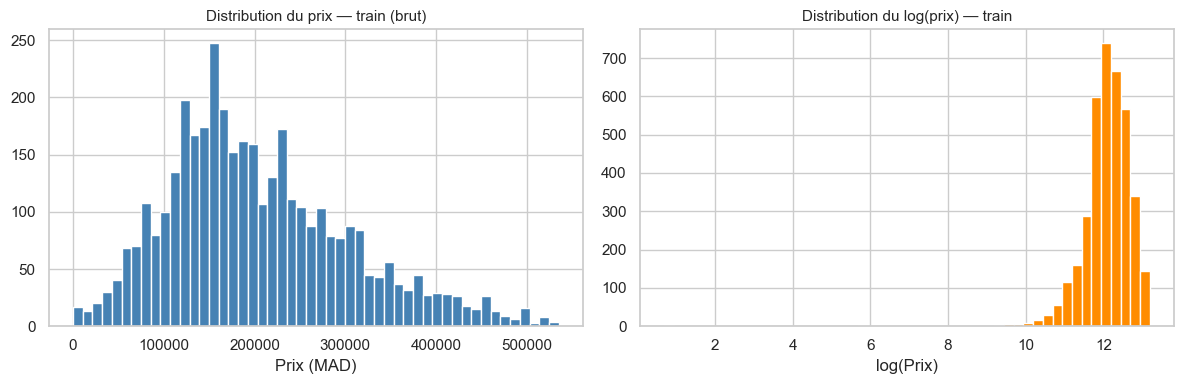

Variables log_prix créées : y_train_log et y_test_log


In [19]:
# Distribution de la cible PRIX
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_train, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution du prix — train (brut)', fontsize=11)
axes[0].set_xlabel('Prix (MAD)')

axes[1].hist(np.log1p(y_train), bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Distribution du log(prix) — train', fontsize=11)
axes[1].set_xlabel('log(Prix)')

plt.tight_layout()
plt.show()

# Transformation log1p de la cible (utile pour modèles linéaires)
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)
print('Variables log_prix créées : y_train_log et y_test_log')

---
## STEP 10 — Aperçu du dataset final

In [20]:
print(f'Train : {X_train.shape[0]} lignes × {X_train.shape[1]} colonnes')
print(f'Test  : {X_test.shape[0]} lignes × {X_test.shape[1]} colonnes')
print(f'NaN restants — train : {X_train.isnull().sum().sum()}')
print(f'NaN restants — test  : {X_test.isnull().sum().sum()}')
print()
X_train.describe().round(3)

Train : 3759 lignes × 17 colonnes
Test  : 940 lignes × 17 colonnes
NaN restants — train : 0
NaN restants — test  : 0



,Kilométrage,Puissance fiscale,État du véhicule,Navigation GPS,Ordinateur de bord,Limiteur de vitesse,Climatisation,Intérieur cuir,Radar de recul,age_voiture,km_par_an,score_options,voiture_recente,Transmission_enc,Marque_enc,Modèle_enc,ville_enc
count,3759.000,3759.000,3759.000,3759.000,3759.000,3759.000,3759.000,3759.000,3759.000,3759.000,3759.000,3759.000,3759.000,3759.000,3759.000,3759.000,3759.000
mean,-0.000,0.000,0.000,0.000,0.000,0.000,-0.000,0.000,0.000,0.000,-0.000,-0.000,0.000,0.000,0.000,0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-1.566,-3.098,-0.454,-0.907,-1.002,-1.074,-1.201,-0.729,-1.051,-1.454,-1.592,-1.239,-1.328,-0.872,-3.752,-2.658,-3.535
25%,-0.748,-0.925,-0.454,-0.907,-1.002,-1.074,-1.201,-0.729,-1.051,-0.739,-0.532,-1.239,-1.328,-0.872,-0.786,-0.765,-0.683
50%,-0.101,-0.200,-0.454,-0.907,0.998,0.931,0.833,-0.729,0.951,-0.202,-0.057,0.137,0.753,-0.872,0.086,-0.145,0.775
75%,0.670,0.525,-0.454,1.103,0.998,0.931,0.833,1.371,0.951,0.334,0.413,1.170,0.753,1.147,0.550,0.883,0.775
max,2.866,2.698,2.203,1.103,0.998,0.931,0.833,1.371,0.951,11.064,16.633,1.170,0.753,1.147,3.138,3.458,0.901


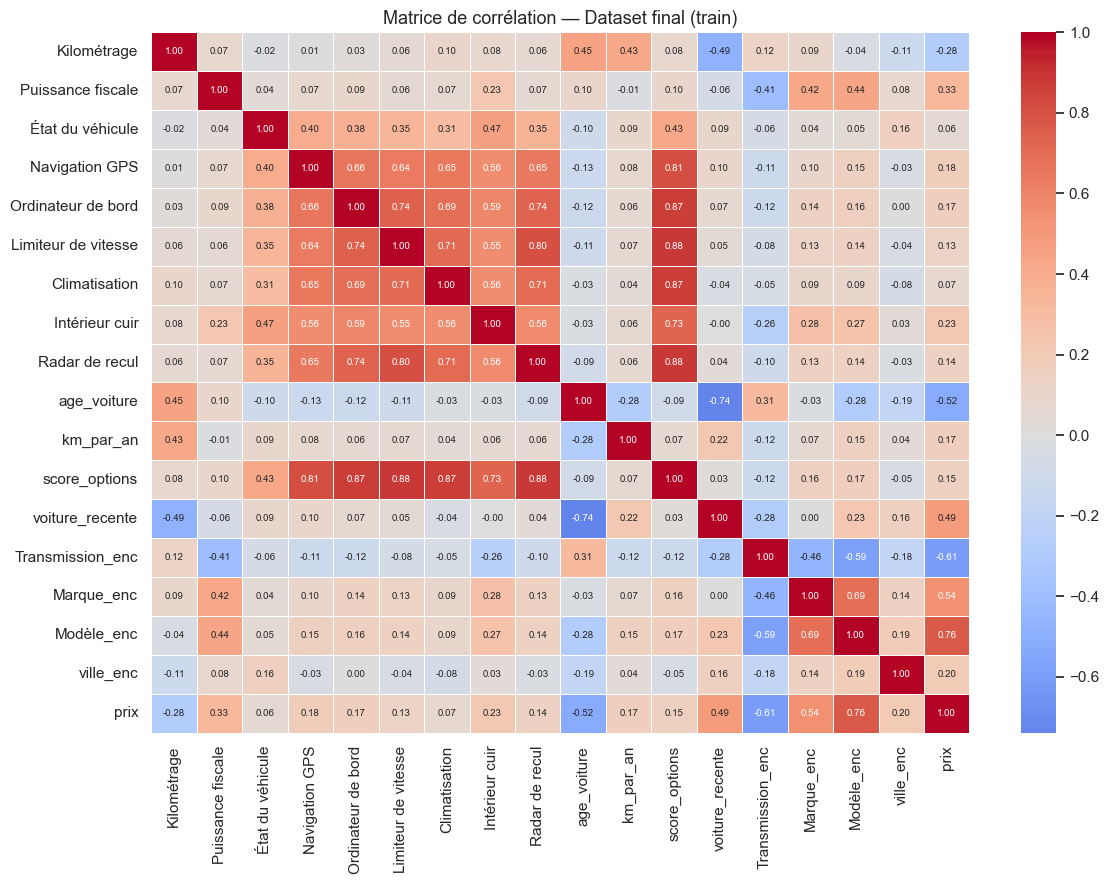

In [21]:
# Heatmap de corrélation finale (sur train)
train_final = X_train.copy()
train_final['prix'] = y_train.values

plt.figure(figsize=(12, 9))
sns.heatmap(
    train_final.corr(numeric_only=True),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, annot_kws={'size': 7}
)
plt.title('Matrice de corrélation — Dataset final (train)', fontsize=13)
plt.tight_layout()
plt.show()

---
## STEP 11 — Sauvegarde des datasets

In [22]:
# Sauvegarde des 4 fichiers : X_train, X_test, y_train, y_test
X_train_path = '../Downloads/X_train.csv'
X_test_path  = '../Downloads/X_test.csv'
y_train_path = '../Downloads/y_train.csv'
y_test_path  = '../Downloads/y_test.csv'

X_train.to_csv(X_train_path, index=False)
X_test.to_csv(X_test_path,   index=False)
y_train.to_csv(y_train_path, index=False)
y_test.to_csv(y_test_path,   index=False)

print(f'Sauvegardé :')
print(f'  {X_train_path}  → {X_train.shape}')
print(f'  {X_test_path}   → {X_test.shape}')
print(f'  {y_train_path}  → {y_train.shape}')
print(f'  {y_test_path}   → {y_test.shape}')
print(f'\nArtifacts ML sauvegardés :')
print(f'  scaler.pkl, le_carburant.pkl, le_transmission.pkl, target_encoders.pkl')

Sauvegardé :
  ../Downloads/X_train.csv  → (3759, 17)
  ../Downloads/X_test.csv   → (940, 17)
  ../Downloads/y_train.csv  → (3759,)
  ../Downloads/y_test.csv   → (940,)

Artifacts ML sauvegardés :
  scaler.pkl, le_carburant.pkl, le_transmission.pkl, target_encoders.pkl
